In [2]:
# Librerías
##Tratamiento de datos
import pandas as pd
import numpy as np
from sklearn import datasets

##Gráficos
import matplotlib.pyplot as plt
import seaborn as sb

##Análsis Estadístico
import scipy

##Advertencias
import warnings
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv("datos_caso_4.csv")
data

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P11995,37,Male,IL,Springfield,195,109,28.7,Medicaid,NaN,0,4,4581.0,2025-09-20,122,1
1996,P11996,32,Female,NY,Rochester,151,94,41.2,Private,NaN,0,1,329.0,2025-08-23,150,1
1997,P11997,50,Female,NC,Unknown,149,115,51.8,Private,Anxiety,1,8,4942.5,2025-05-23,242,1
1998,P11998,74,Female,NC,Unknown,165,97,35.6,Medicare,Heart Disease,3,7,4700.0,2025-07-09,195,1


In [4]:
data.info()
#cuantificar cantidad de nulos por variable
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2000 non-null   object 
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   State                   2000 non-null   object 
 4   City                    2000 non-null   object 
 5   Height_cm               2000 non-null   int64  
 6   Weight_kg               2000 non-null   int64  
 7   BMI                     2000 non-null   float64
 8   Insurance_Type          2000 non-null   object 
 9   Primary_Condition       1505 non-null   object 
 10  Num_Chronic_Conditions  2000 non-null   int64  
 11  Annual_Visits           2000 non-null   int64  
 12  Avg_Billing_Amount      2000 non-null   float64
 13  Last_Visit_Date         2000 non-null   object 
 14  Days_Since_Last_Visit   2000 non-null   

PatientID                   0
Age                         0
Gender                      0
State                       0
City                        0
Height_cm                   0
Weight_kg                   0
BMI                         0
Insurance_Type              0
Primary_Condition         495
Num_Chronic_Conditions      0
Annual_Visits               0
Avg_Billing_Amount          0
Last_Visit_Date             0
Days_Since_Last_Visit       0
Preventive_Care_Flag        0
dtype: int64

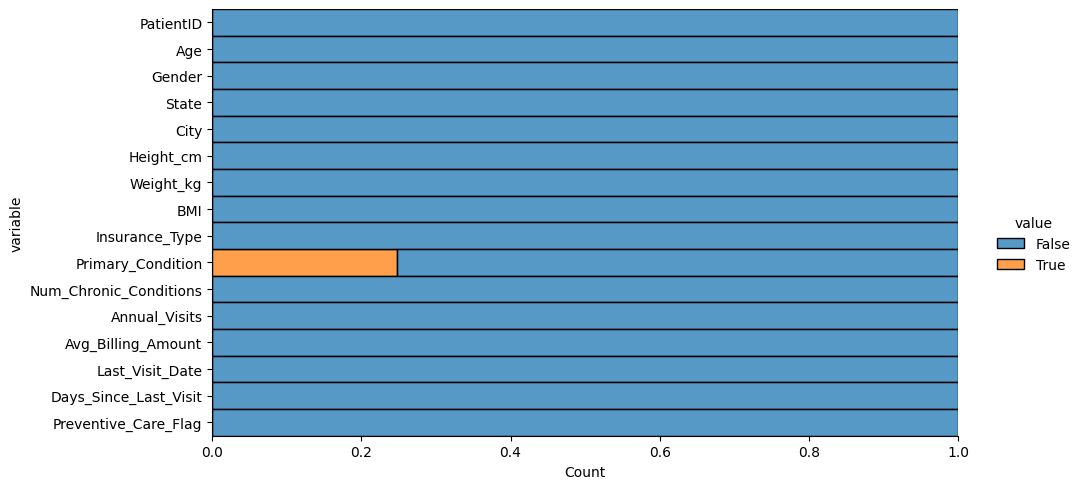

In [5]:
#Vemos la proporcion de datos nulos. 
data.isnull().melt().pipe(lambda df: (sb.displot(data= df, y= 'variable', hue = 'value', multiple= 'fill', aspect=2)))

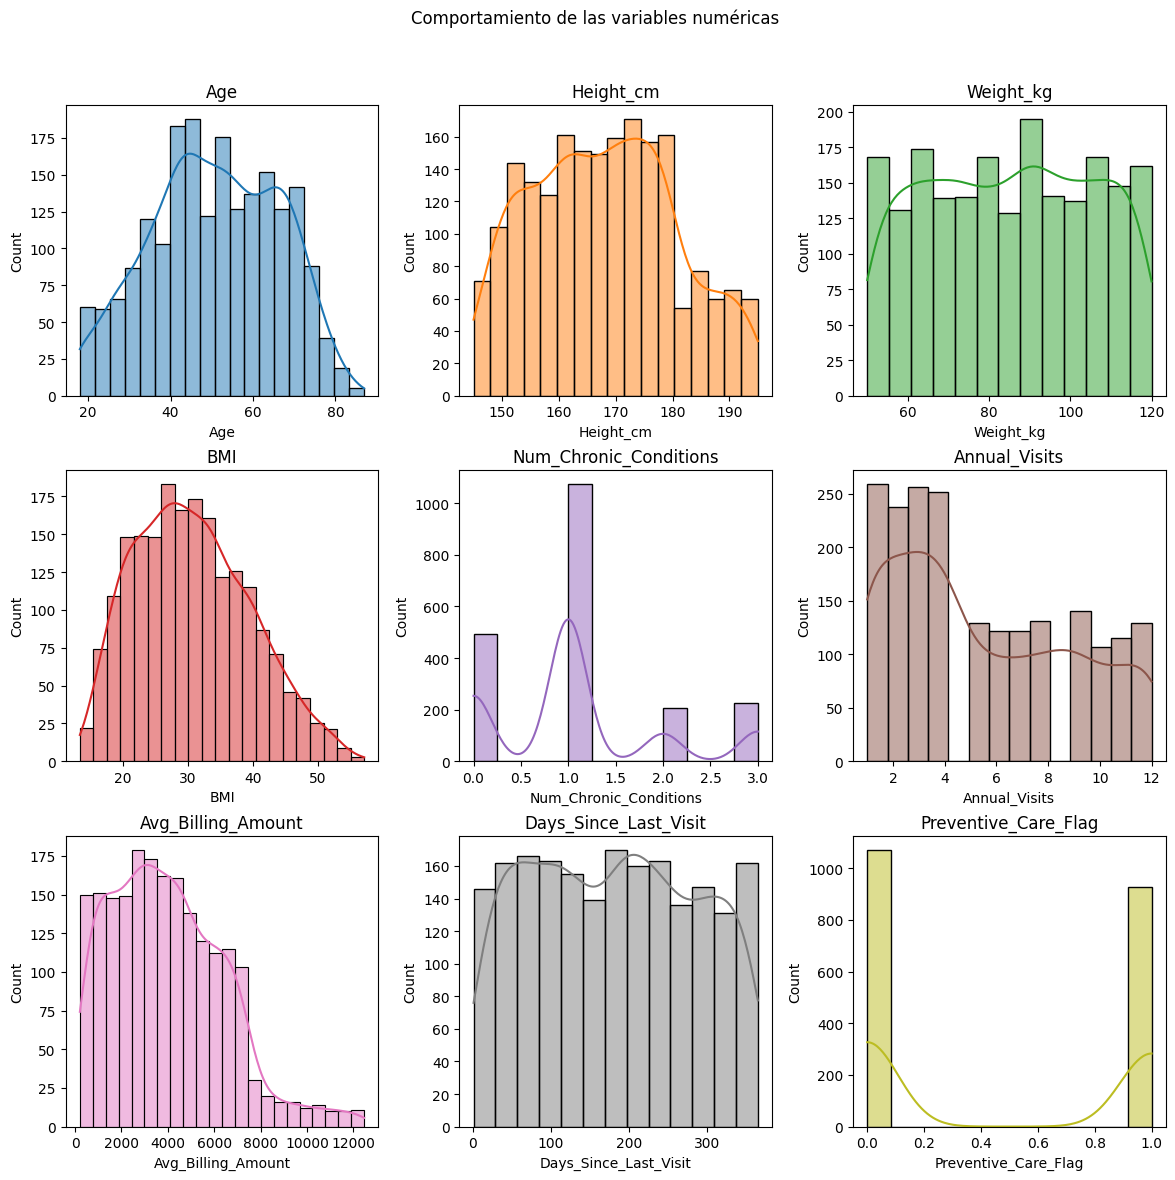

In [6]:
# Construir los histogramas de frecuencia para todas las variabes numéricas
fig, ax = plt.subplots(3, 3, figsize = (12,12))
ax = ax.flat
data = data.drop(columns = 'PatientID')
num_col = data.select_dtypes(include = ['float64', 'int64']).columns
for i, col in enumerate (num_col):
    sb.histplot(data = data, x = col, kde = True, color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], ax= ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de las variables numéricas')
plt.show()

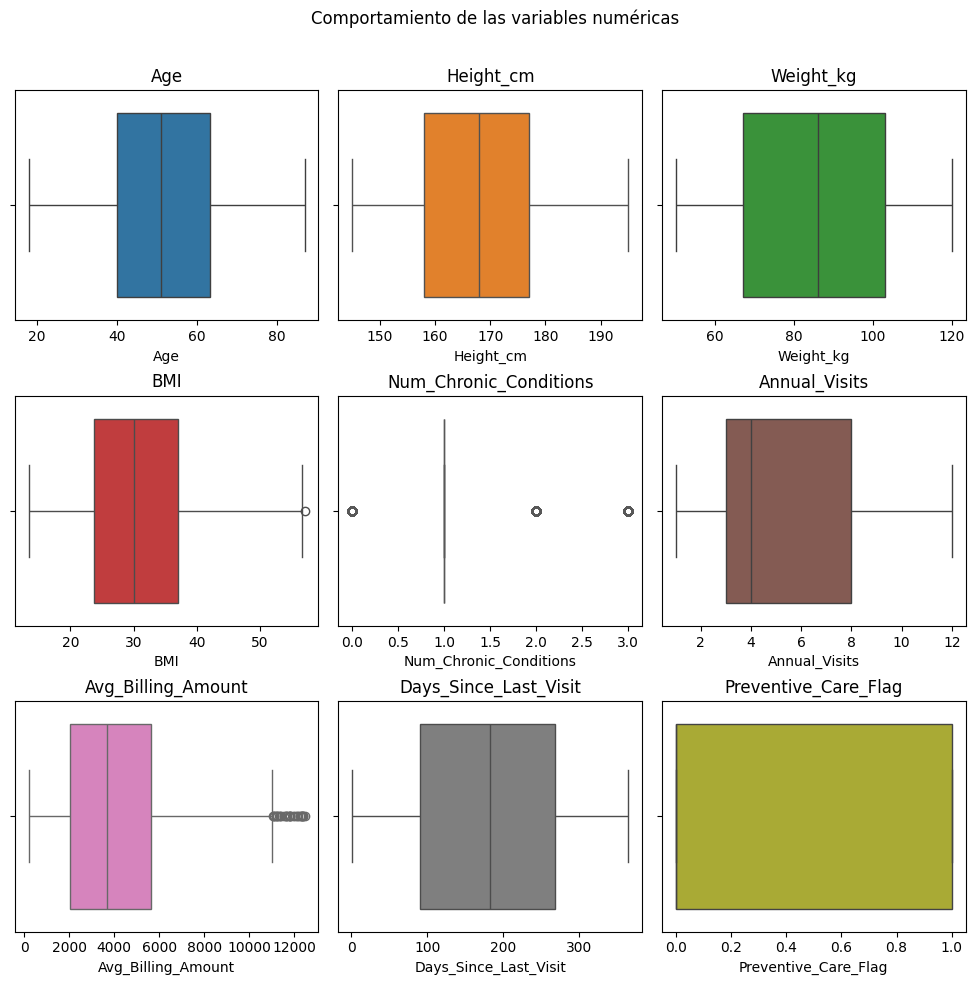

In [7]:
#Construir diagrama de cajas y bigotes
fig, ax = plt.subplots(3, 3, figsize = (10,10))
ax = ax.flat
for i, col in enumerate (num_col):
    sb.boxplot(data = data, x = col, color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], ax= ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de las variables numéricas')
plt.show()


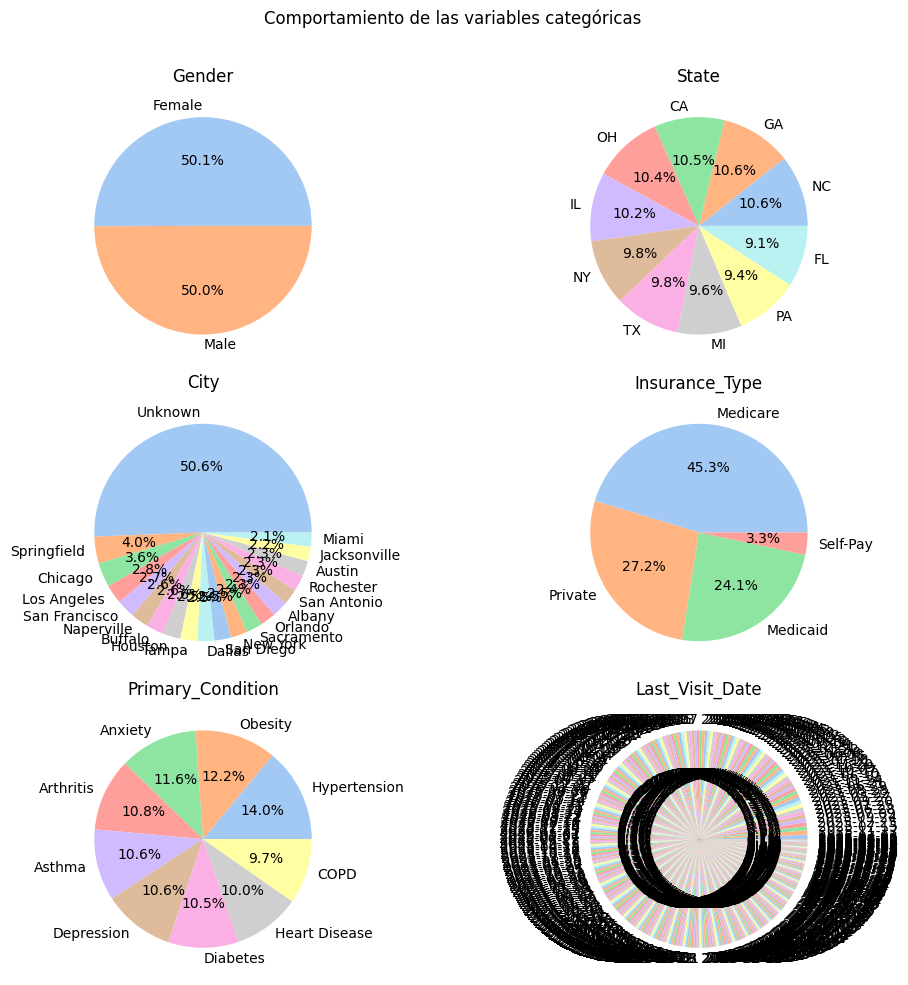

In [8]:
#Gráficos de torta para variables categóricas
cat_col = data.select_dtypes(include = ['object', 'category']).columns
fig, ax = plt.subplots(3, 2, figsize = (10,10))
ax = ax.flat
for i, col in enumerate (cat_col):
    data[col].value_counts().plot.pie(autopct = '%1.1f%%', colors = sb.color_palette('pastel'), ax = ax[i])
    ax[i].set_title(col)
    ax[i].set_ylabel('')
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de las variables categóricas')
plt.show()


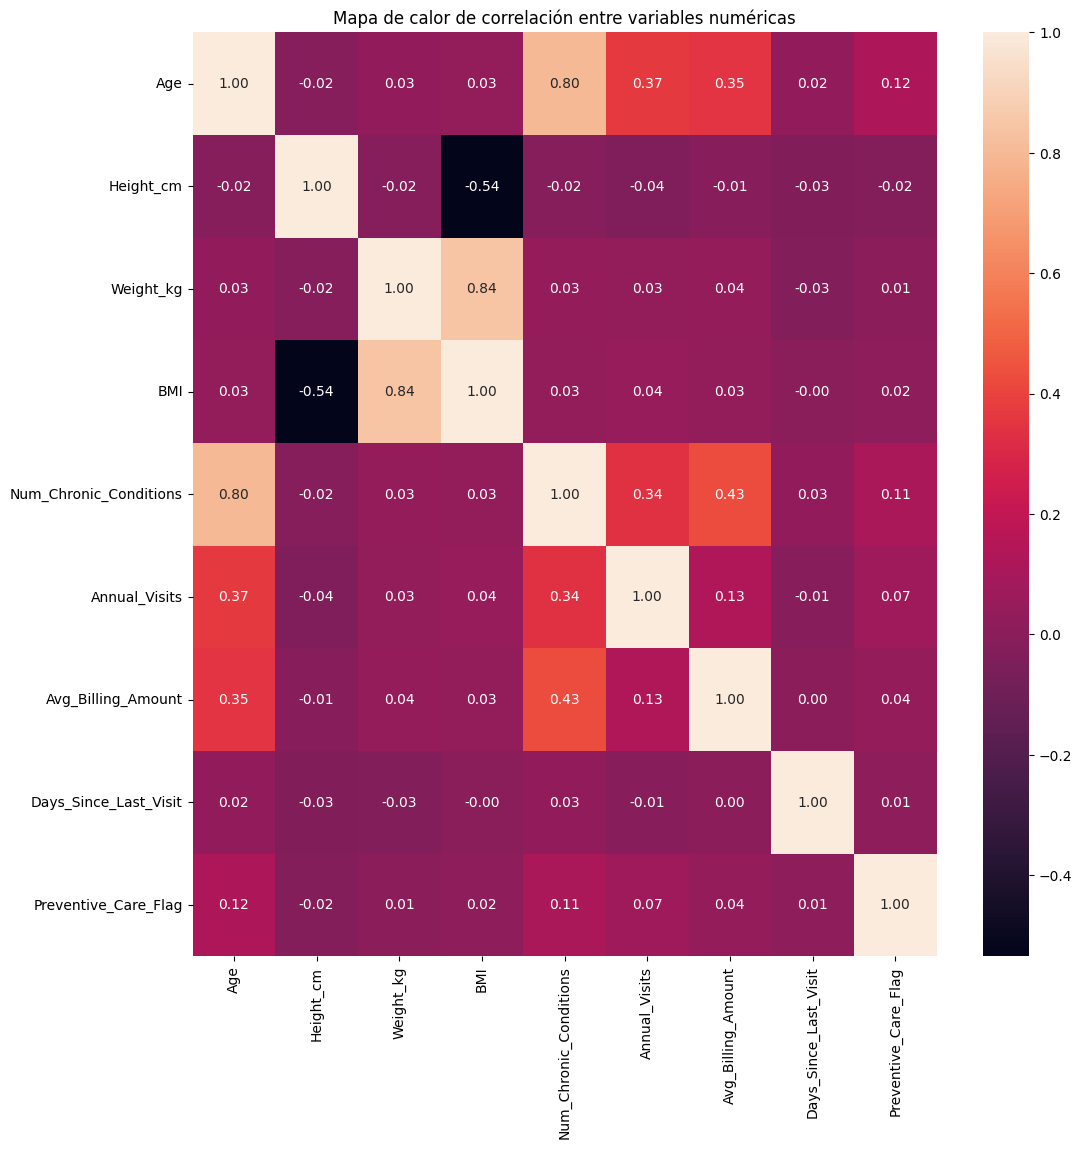

In [9]:
# Mapa de calor de correlación entre variables numéricas
plt.figure(figsize=(12,12))
sb.heatmap(data=data.corr(numeric_only=True),annot=True,fmt="0.2f")
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

In [10]:
#Se eliminan las variables BMI y Num_Chronic_Conditions por su alta correlación con otras variables, Last_Visit_Date por redundancia con Days_Since_Last_Visit y City por su alta cardinalidad.
data_mod = data.drop(columns = ['BMI', 'Num_Chronic_Conditions', 'Last_Visit_Date', 'City'])

#Se completa los registros nulos de la variable Primary_Condition con "None", ya que estos registros coinciden con pacientes que no tienen condiciones crónicas.
data_mod["Primary_Condition"] = data_mod["Primary_Condition"].fillna("None")
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    2000 non-null   int64  
 1   Gender                 2000 non-null   object 
 2   State                  2000 non-null   object 
 3   Height_cm              2000 non-null   int64  
 4   Weight_kg              2000 non-null   int64  
 5   Insurance_Type         2000 non-null   object 
 6   Primary_Condition      2000 non-null   object 
 7   Annual_Visits          2000 non-null   int64  
 8   Avg_Billing_Amount     2000 non-null   float64
 9   Days_Since_Last_Visit  2000 non-null   int64  
 10  Preventive_Care_Flag   2000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 172.0+ KB


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [12]:
#Escalamiento de variables numéricas usando Min-Max Scaler porque las variables numéricas no siguen una distribución normal y queremos mantener la forma de la distribución original.
# Se escalan todas menos Preventive_Care_Flag, que es una variable binaria.
# Codificación de variables categóricas usando One-Hot Encoding porque no hay muchas categorías en las variables categóricas y no hay un orden intrínseco entre las categorías.
# Pipeline de preprocesamiento

# Pipeline de transformación de datos
num_cols = data_mod.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_cols = data_mod.select_dtypes(include = ['object']).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder())])
preprocessor = ColumnTransformer(transformers = [('num', num_transformer, num_cols),
                                                 ('cat', cat_transformer, cat_cols)], remainder = 'passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['Age', 'Height_cm', 'Weight_kg',
                                  'Annual_Visits', 'Avg_Billing_Amount',
                                  'Days_Since_Last_Visit',
                                  'Preventive_Care_Flag']),
                                ('cat',
                                 Pipeline(steps=[('encoder', OneHotEncoder())]),
                                 ['Gender', 'State', 'Insurance_Type',
                                  'Primary_Condition'])])

In [13]:
# Se aploica el preprocesamiento a los datos
data_pre = preprocessor.fit_transform(data_mod)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out()
labels = np.concatenate([num_cols, cod_cat])
data_pro = pd.DataFrame(data_pre, columns = labels)
data_pro


,Age,Height_cm,Weight_kg,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Gender_Female,Gender_Male,State_CA,...,Primary_Condition_Anxiety,Primary_Condition_Arthritis,Primary_Condition_Asthma,Primary_Condition_COPD,Primary_Condition_Depression,Primary_Condition_Diabetes,Primary_Condition_Heart Disease,Primary_Condition_Hypertension,Primary_Condition_None,Primary_Condition_Obesity
0,0.666667,0.12,0.928571,0.545455,0.227397,0.508242,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.594203,0.88,0.257143,0.636364,0.081726,0.104396,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.579710,0.22,0.585714,0.272727,0.064598,0.343407,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.362319,0.14,0.600000,0.454545,0.443008,0.782967,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.507246,0.44,0.014286,0.272727,0.455854,0.873626,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.275362,1.00,0.842857,0.272727,0.356755,0.332418,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1996,0.202899,0.12,0.628571,0.000000,0.009951,0.409341,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1997,0.463768,0.08,0.928571,0.636364,0.386240,0.662088,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.811594,0.40,0.671429,0.545455,0.366461,0.532967,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [14]:
### Método KMeans
from sklearn.cluster import KMeans

In [15]:
cluster_range = range(2, 20) #Haz Kmeans con entre 2 y 20 centros
inertia = []
for n_cluster in cluster_range:
  kmeans_model = KMeans(n_clusters = n_cluster, random_state = 42, n_init=20) #Por cada centro intenta 20 veces y quedate con el de mejor inercia
  kmeans_model.fit(data_pro) #Entrena el modelo con los centros de lo de la linea anterior
  inertia.append(kmeans_model.inertia_) #guardamos inercia para cada elemento del rango

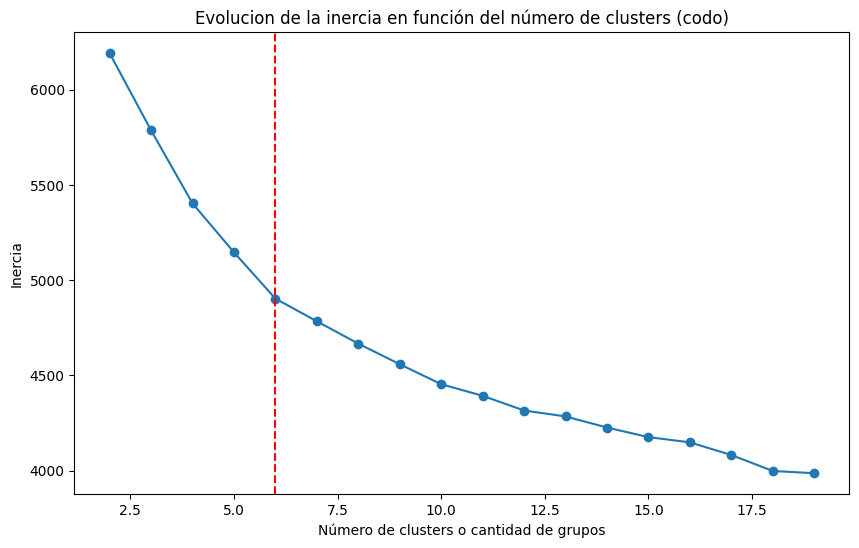

In [16]:
plt.figure(figsize = (10, 6))
plt.plot(cluster_range, inertia, marker = 'o')
plt.axvline(x = 6, color = 'red', linestyle = '--')
plt.title('Evolucion de la inercia en función del número de clusters (codo)')
plt.xlabel('Número de clusters o cantidad de grupos')
plt.ylabel('Inercia')
plt.show()

In [17]:
kmeans_final_model = KMeans(n_clusters = 6, random_state = 42, n_init=20)
kmeans_final_model.fit(data_pro)

KMeans(n_clusters=6, n_init=20, random_state=42)

In [18]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

In [19]:
#Función para dibujar el dendrograma
def dibujarDendrograma(model, **kwargs):
    counts = np.zeros(model.children_.shape[0]) #Cuantos pacientes tiene un cluster y crea un arreglo de ceros de ese tamano. Children shape 0 cuenta numero de merges. Model.children tiene todos los merge (hijo1,hijo2)
    n_samples = len(model.labels_) #model.labels es n de pacientes
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node - cuenta los pacientes individuales 
            else:
                current_count += counts[child_idx - n_samples] #La resta mira el numero de cluster (sin contar los individuales), entnces en current counts se asigna el numero de pacientes en ese cluster. Ese for pequeno cuenta los pacientes de cada merge
        counts[i] = current_count #En el merge i que estamos viendo, le asigno e valor de pacientes en el arreglo. El arreglo counts queda con el numero de pacientes de cada merge.
                                  #En counts solo quedan los clusters que no son clusters individuales
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float) #Tabla que dice quien se une con quien, cual fue la distancia y cuantos pacientes tiene el cluster

    # Plot
    dendrogram(linkage_matrix, **kwargs) #con la linkage_matrix que creamos se construye el dendograma

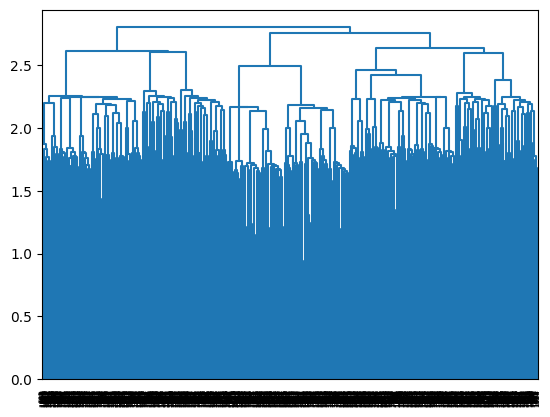

In [20]:
h_clust_avg = AgglomerativeClustering(metric = 'euclidean', linkage = 'average', distance_threshold = 0, n_clusters = None)
h_clust_avg.fit(X = data_pro) 
dibujarDendrograma(h_clust_avg, color_threshold = 0)

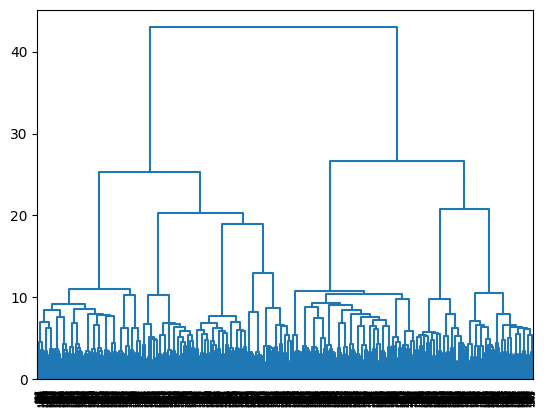

In [21]:
#Varianza
h_clust_var = AgglomerativeClustering(metric = 'euclidean', linkage = 'ward', distance_threshold = 0, n_clusters = None)
h_clust_var.fit(X = data_pro)
dibujarDendrograma(h_clust_var, color_threshold = 0)

<function matplotlib.pyplot.show(close=None, block=None)>

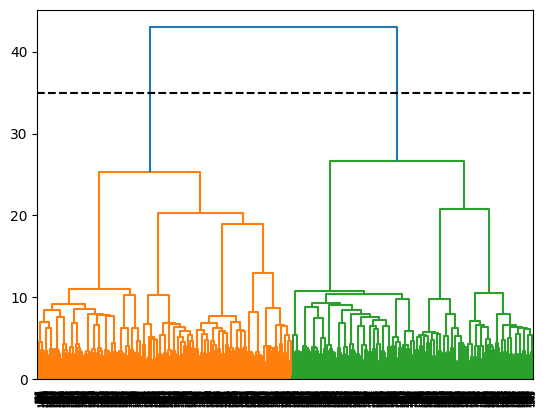

In [22]:
dendrogram_prun = 35
dibujarDendrograma(h_clust_var, color_threshold = dendrogram_prun)
plt.axhline(y = dendrogram_prun, c = 'black', linestyle = '--')
plt.show

In [23]:
h_cluster_final = AgglomerativeClustering(metric = 'euclidean', linkage = 'ward', n_clusters = 2)
h_cluster_final.fit(data_pro)


AgglomerativeClustering()

In [24]:
#DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from itertools import product

##Epsilon, a que distancia es vecino?, minpts, hay suficientes puntos para considerarlo un cluster?
#Core point (núcleo): Tiene al menos min_samples vecinos dentro de eps (incluyéndose a sí mismo según implementación).
#Border point (borde) No alcanza min_samples, pero está dentro del eps de un punto core.
#Noise / Outlier: No es core ni está cerca de un core. DBSCAN lo etiqueta como -1 en sklearn.
#Varios cores forman un cluster si estan en una cadena de cores.

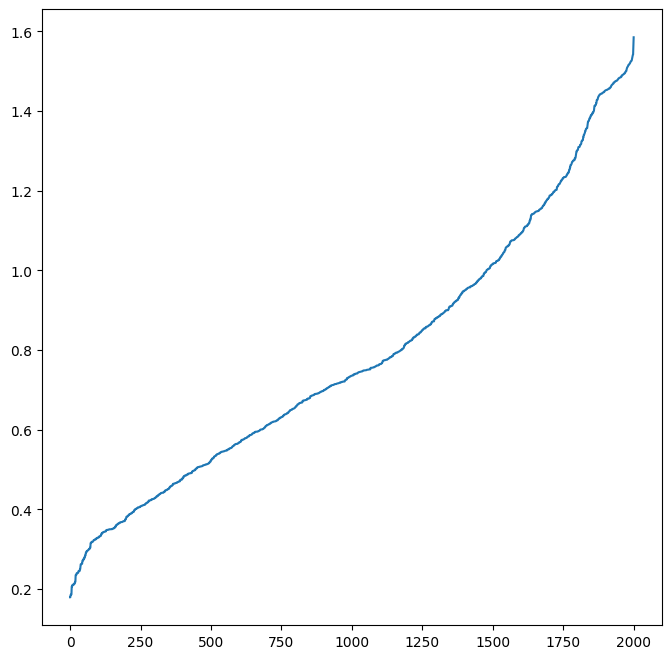

In [25]:
neighbors = NearestNeighbors()
neighbors_fit = neighbors.fit(data_pro) #Almacena los datos y crea una estructura para encontrar vecinos facil
distance, indices = neighbors_fit.kneighbors(data_pro) #Kneighbors devuelve matriz de indices (que vecinos) y distancia (que tan lejos estan)
distance = np.sort(distance, axis = 0) #ordena las distanciasa POR COLUMNA - se pierde el sentido individual pero perimte ver distribucion de distancias
distance = distance[:,1] #devuelve vector de distancias al vecino mas cercano
plt.figure(figsize = (8,8))
plt.plot(distance)
plt.show()
#Nos ayuda a elgeir epsilon para DBscan

    Epsilon  Vecindad     Score
0       1.0         2  0.217042
1       1.0         3  0.037301
2       1.0         4 -0.114892
3       1.0         5 -0.179155
4       1.0         6 -0.204339
..      ...       ...       ...
83      1.5         5 -0.013235
84      1.5         6 -0.012500
85      1.5         7 -0.072497
86      1.5         8 -0.104027
87      1.5         9 -0.100219

[88 rows x 3 columns]


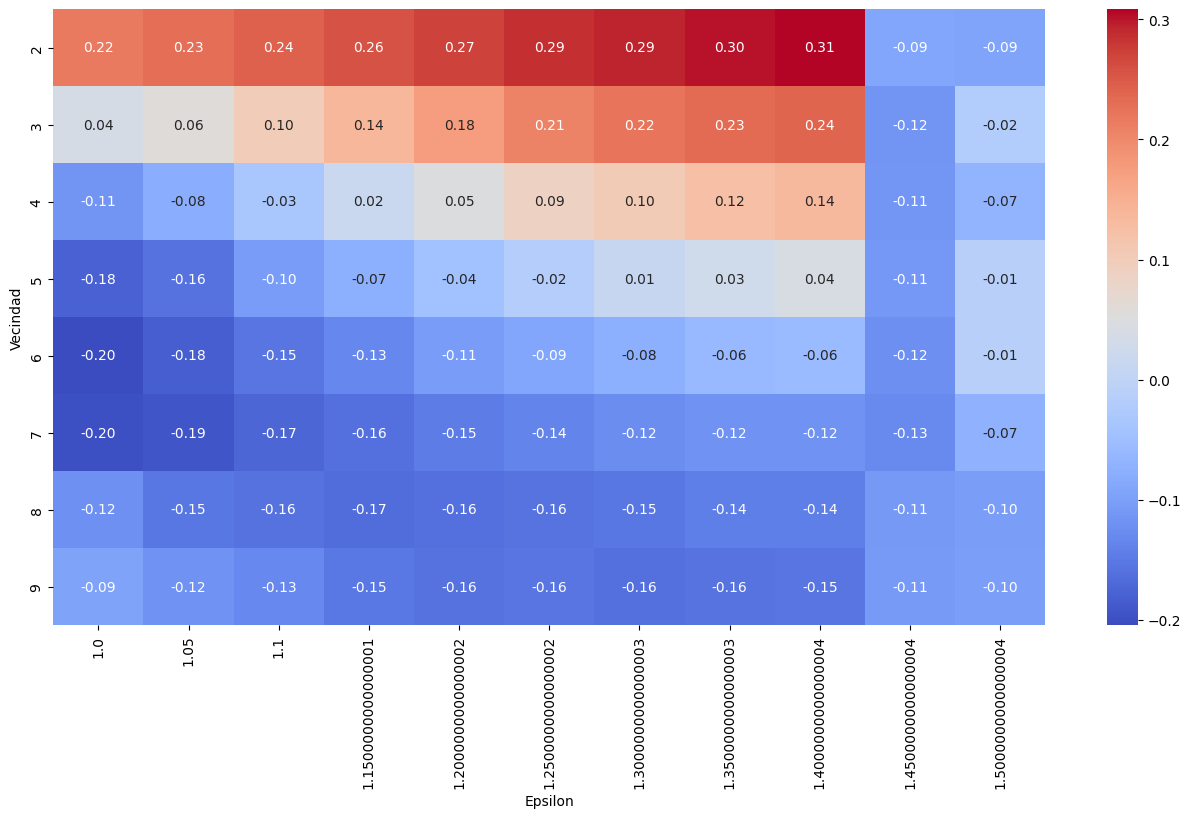

In [ ]:
#Probamos diferentes combinaciones de epsilon y min_samples a ver cual da mejor

from sklearn.metrics import silhouette_score
from itertools import product

eps_values = np.arange(1, 1.65, 0.05) #Valores de 1 a 1.65 no incluido
samples = np.arange(2, 10) #de 2 a 10 no incluido
dbscan_params = list(product(eps_values, samples)) #Me almacena todas las combinaciones de epsilon y samples
sil_scores = []

for p in dbscan_params:
  y_pred = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(data_pro) # fit encuentre cluster, predict asigna a paciente. Devuelve arreglo de numeros de cluster al que pertenece cada paciente
  n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0) #set elmina repetidos y len los cuenta. Si hay -1 (ruido) devuelve 1 sino 0. 
  if n_clusters >= 2:
    sil_scores.append(silhouette_score(data_pro, y_pred)) #anade la silhouette a lalista
  else:
    sil_scores.append(np.nan)  #Si solo hay un cluster poner nan

df_param_adj = pd.DataFrame.from_records(dbscan_params, columns=['Epsilon', 'Vecindad'])
df_param_adj['Score'] = sil_scores

# Optional: filter out NaN scores to see only valid results
print(df_param_adj[df_param_adj['Score'].notna()])

#Verlo en heatmap
pivot_data = pd.pivot_table(df_param_adj, values='Score', index='Vecindad', columns='Epsilon')
plt.figure(figsize=(16, 8))
sb.heatmap(pivot_data, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [27]:
dbscan_final = DBSCAN(eps= 1.4, min_samples= 2)
dbscan_final.fit(data_pro)

DBSCAN(eps=1.4, min_samples=2)

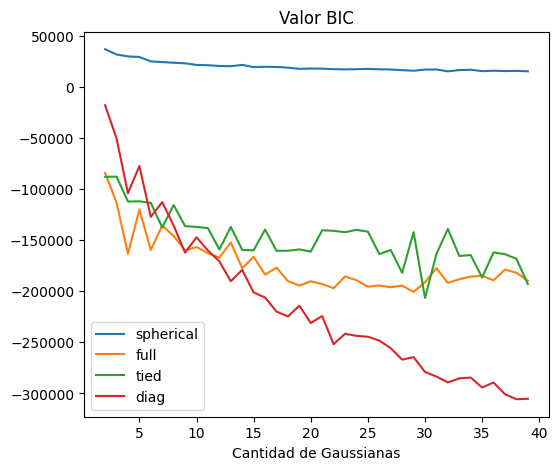

In [ ]:
#GMM
#un punto tiene probabilidad de pertenecer a varios clusters
from sklearn.mixture import GaussianMixture
fig, ax = plt.subplots(figsize = (6,5))
n_gauss = range(2, 40) #Intenta con 2 a 40 gaussianas 
var_type = ['spherical', 'full', 'tied', 'diag']
for cov_type in var_type:
    valor_bic=[  ]
    for i in n_gauss:
        model = GaussianMixture(n_components = i, covariance_type = cov_type) #n_components = numero gaussianas actual, cov typeforma de gaussiana
        model.fit(data_pro) #entrenar modelo (donde estan las gaussianas, que forma y tamano tienen, que tan grandes son)
        valor_bic.append(model.bic(data_pro))
    ax.plot(n_gauss, valor_bic, label = cov_type)
ax.set_title('Valor BIC')
ax.set_xlabel('Cantidad de Gaussianas')
ax.legend()
plt.show()

#BIC busca equilibrio entre ajuste y complejidad. entre mas bajo mejor


In [55]:
gmm_final = GaussianMixture(n_components = 39, covariance_type = 'diag')
gmm_final.fit(data_pro)


GaussianMixture(covariance_type='diag', n_components=39)

In [ ]:
# a cada fila de data_pro le asignan un número que dice a que cluster pertenece. Devuelve un vector
labels_kmeans = kmeans_final_model.predict(data_pro)
labels_h_clust= h_cluster_final.fit_predict(data_pro)
labels_dbscan = dbscan_final.fit_predict(data_pro)
labels_gmm = gmm_final.predict(data_pro)

In [ ]:
#Silhouette: que tan bien ubicado esta cada paciente en su cluster
sil_kmeans= silhouette_score(data_pro, labels_kmeans)
sil_h = silhouette_score(data_pro, labels_h_clust)
sil_dbscan = silhouette_score(data_pro, labels_dbscan)
sil_gmm = silhouette_score(data_pro, labels_gmm)
print(f"Silhouette Score KMeans: {sil_kmeans:.3f}")
print(f"Silhouette Score Hierarchical: {sil_h:.3f}")
print(f"Silhouette Score DBSCAN: {sil_dbscan:.3f}")
print(f"Silhouette Score GMM: {sil_gmm:.3f}")

Silhouette Score KMeans: 0.150
Silhouette Score Hierarchical: 0.124
Silhouette Score DBSCAN: 0.308
Silhouette Score GMM: 0.126


In [32]:
# Identificar cuántos grupos se formaron en cada modelo
n_clusters_kmeans = len(np.unique(labels_kmeans))
n_clusters_h_clust = len(np.unique(labels_h_clust))
n_clusters_dbscan = len(np.unique(labels_dbscan))
n_clusters_gmm = len(np.unique(labels_gmm))
print(f"Número de clusters KMeans: {n_clusters_kmeans}")
print(f"Número de clusters Hierarchical: {n_clusters_h_clust}")
print(f"Número de clusters DBSCAN: {n_clusters_dbscan}")
print(f"Número de clusters GMM: {n_clusters_gmm}")

Número de clusters KMeans: 6
Número de clusters Hierarchical: 2
Número de clusters DBSCAN: 432
Número de clusters GMM: 39


In [33]:
# Se descarta DBSCAN por su alto numero de clusters. 
# Nos quedamos con kmeans porque tiene el segundo mejor índice de silhouette y un número de clusters adecuado para segmentar a los pacientes.
# Nos quedamos con kmeans porque tiene el segundo mejor índice de silhouette y un número de clusters adecuado para segmentar a los clientes de la aerolínea.
# Además, tiene la ventaja de que tengo información de los centros, que en kmeans representan la media de cada cluster, lo que me permite interpretar mejor los grupos y entender las características comunes de los clientes en cada cluster. En cambio, en el modelo jerárquico no tengo esta información de los centros, lo que dificulta la interpretación de los clusters.
# Hay que decodificar y desescalar los centros para poder interpretar los resultados de los centros 
centers = pd.DataFrame(kmeans_final_model.cluster_centers_)
centers.columns=np.concatenate([num_cols, cod_cat])
centers



,Age,Height_cm,Weight_kg,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Gender_Female,Gender_Male,State_CA,...,Primary_Condition_Anxiety,Primary_Condition_Arthritis,Primary_Condition_Asthma,Primary_Condition_COPD,Primary_Condition_Depression,Primary_Condition_Diabetes,Primary_Condition_Heart Disease,Primary_Condition_Hypertension,Primary_Condition_None,Primary_Condition_Obesity
0,0.373843,0.556305,0.497017,0.373129,0.295366,0.493766,0.489960,-2.220446e-16,1.000000e+00,0.108434,...,0.084337,0.052209,0.044177,0.076305,0.084337,0.076305,0.104418,0.072289,0.341365,0.064257
1,0.365077,0.550645,0.508571,0.370088,0.272070,0.471562,0.383871,0.000000e+00,1.000000e+00,0.103226,...,0.064516,0.070968,0.064516,0.064516,0.054839,0.070968,0.061290,0.096774,0.361290,0.090323
2,0.613547,0.354893,0.494421,0.480492,0.367257,0.501421,0.508584,1.000000e+00,-1.665335e-16,0.111588,...,0.126609,0.100858,0.107296,0.075107,0.079399,0.092275,0.081545,0.122318,0.083691,0.130901
3,0.338254,0.391791,0.499680,0.342605,0.267466,0.510804,0.436567,1.000000e+00,5.551115e-17,0.067164,...,0.048507,0.078358,0.055970,0.059701,0.085821,0.074627,0.048507,0.063433,0.444030,0.041045
4,0.397872,0.346367,0.493686,0.408240,0.281058,0.505813,0.486891,1.000000e+00,1.110223e-16,0.123596,...,0.086142,0.086142,0.078652,0.056180,0.097378,0.063670,0.052434,0.108614,0.292135,0.078652
5,0.587813,0.555045,0.514903,0.408471,0.325059,0.475549,0.461364,3.330669e-16,1.000000e+00,0.106818,...,0.088636,0.084091,0.097727,0.093182,0.081818,0.084091,0.090909,0.134091,0.140909,0.104545


In [34]:
# Revertir la codificación y el escalamiento
num_inverse_transformer=preprocessor.named_transformers_['num']['scaler']
cent_num_inverse=num_inverse_transformer.inverse_transform(centers[num_cols])
cat_inverse_transformer=preprocessor.named_transformers_['cat']['encoder']
cent_cat_inverse=cat_inverse_transformer.inverse_transform(centers[cod_cat])
transformed_centers = pd.DataFrame(np.concatenate([cent_num_inverse, cent_cat_inverse], axis = 1), columns = np.concatenate([num_cols, cat_cols]))
transformed_centers

,Age,Height_cm,Weight_kg,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Gender,State,Insurance_Type,Primary_Condition
0,43.795181,172.815261,84.791165,5.104418,3828.331325,180.730924,0.48996,Male,OH,Medicaid,None
1,43.190323,172.532258,85.6,5.070968,3542.716129,172.648387,0.383871,Male,MI,Private,None
2,60.334764,162.744635,84.609442,6.285408,4709.753219,183.517167,0.508584,Female,NC,Medicare,Obesity
3,41.339552,164.589552,84.977612,4.768657,3486.270522,186.932836,0.436567,Female,MI,Medicaid,None
4,45.453184,162.318352,84.558052,5.490637,3652.913858,185.116105,0.486891,Female,CA,Private,None
5,58.559091,172.752273,86.043182,5.493182,4192.388636,174.1,0.461364,Male,IL,Medicare,None
